# 04a — Event-Study Trajectory Plot (Junior vs Senior)

Reads `04_trajectory_long.csv` (per-author, per-relative-year works/citations, saved from notebook
04's in-memory `all_works` — no re-fetch needed). Reproduces the thesis-style event-study plot:
median with bootstrapped 95% CI per relative year, -5 to +5 years around the award.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA_DIR = Path('../conf_data')
FIG_DIR = Path('../conf_figures')
FIG_DIR.mkdir(exist_ok=True)

long_df = pd.read_csv(DATA_DIR / '04_trajectory_long.csv')
print(long_df.shape)
long_df.head()


(23721, 5)


,author_id,treatment,rel_year,works,citations
0,https://openalex.org/A5000009841,1,-1,1,9
1,https://openalex.org/A5000009841,1,0,1,308
2,https://openalex.org/A5000009841,1,2,3,186
3,https://openalex.org/A5000009841,1,3,6,154
4,https://openalex.org/A5000009841,1,4,3,271


In [2]:
def bootstrap_median_ci(data, n_boot=1000, ci=0.95, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    arr = np.asarray(data)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan
    boot = np.median(rng.choice(arr, size=(n_boot, len(arr)), replace=True), axis=1)
    alpha = (1 - ci) / 2
    return np.percentile(boot, 100 * alpha), np.percentile(boot, 100 * (1 - alpha))


def traj_stats(df, treatment_val, metric, rel_years, n_boot=1000):
    rng = np.random.default_rng(42)
    sub = df[df['treatment'] == treatment_val]
    medians, lo_ci, hi_ci = [], [], []
    for ry in rel_years:
        vals = sub.loc[sub['rel_year'] == ry, metric].dropna().values
        medians.append(np.median(vals) if len(vals) else np.nan)
        lo, hi = bootstrap_median_ci(vals, n_boot=n_boot, rng=rng)
        lo_ci.append(lo)
        hi_ci.append(hi)
    return np.array(medians), np.array(lo_ci), np.array(hi_ci)


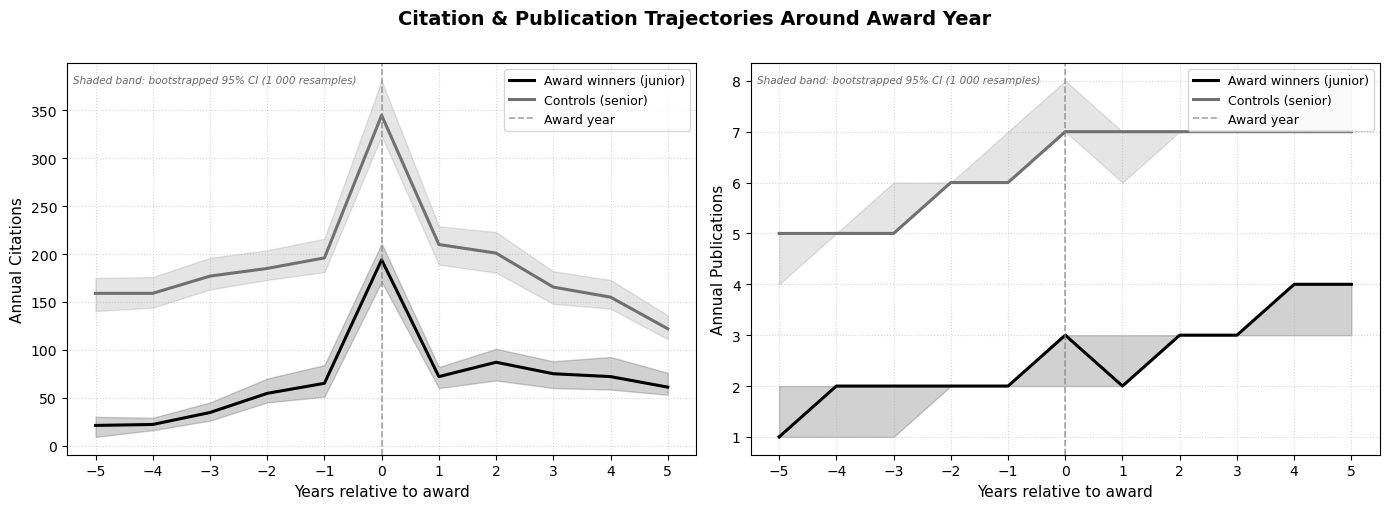

Saved: 04_lift_trajectories.png


In [3]:
REL_YEARS = list(range(-5, 6))
WINDOW = long_df[long_df['rel_year'].between(-5, 5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Citation & Publication Trajectories Around Award Year",
             fontsize=14, fontweight="bold", y=1.01)

configs = [
    (axes[0], "citations", "Annual Citations"),
    (axes[1], "works", "Annual Publications"),
]

for ax, metric, ylabel in configs:
    for treat_val, label, color in [
        (1, "Award winners (junior)", "#000000"),
        (0, "Controls (senior)", "#707070"),
    ]:
        med, lo, hi = traj_stats(WINDOW, treat_val, metric, REL_YEARS)
        ax.plot(REL_YEARS, med, color=color, lw=2.2, label=label)
        ax.fill_between(REL_YEARS, lo, hi, color=color, alpha=0.18, label="_nolegend_")

    ax.axvline(0, color="gray", linestyle="--", lw=1.2, alpha=0.7, label="Award year")
    ax.set_xlabel("Years relative to award", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.text(0.01, 0.97, "Shaded band: bootstrapped 95% CI (1 000 resamples)",
            transform=ax.transAxes, fontsize=7.5, va="top", color="dimgray", style="italic")

plt.tight_layout()
out_path = FIG_DIR / "04_lift_trajectories.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path.name}")


## Data Provenance Log Update

In [4]:
log_path = DATA_DIR / '00_data_sources_log.md'

new_entries = [
    "",
    "## Notebook 04a — Event-study trajectory plot (thesis-style)",
    "- Reads 04_trajectory_long.csv, generated from notebook 04's in-memory all_works (no re-fetch).",
    f"- Trajectory rows: {len(long_df)}, window -5 to +5 years relative to award.",
    "- Chart: median + bootstrapped 95% CI (1000 resamples) per relative year, Junior vs Senior, "
    "matching thesis notebook 11 style (11_lift_trajectories.png).",
    "",
    "### Output files",
    "- conf_figures/04_lift_trajectories.png — citation & publication trajectories around award year",
]

with open(log_path, 'a') as f:
    f.write("\n".join(new_entries))

print("Log updated.")


Log updated.
